In [1]:
import pandas as pd

In [2]:
scai_data = pd.read_csv('../data/scai_data/scai_data.csv')
scai_data

,fips,hospitals_per_100k,hospital_beds_per_100k,pcp_per_100k,neurologists_per_100k,stroke_centers_per_100k
0,9001,0.830065,166.635539,95.249953,6.017971,0.622549
1,9003,0.890395,199.782299,95.272227,6.789259,0.667796
2,9009,1.039601,210.807920,85.478280,16.287078,0.808578
3,9011,0.744829,157.531339,62.193224,3.351731,0.744829
4,9005,1.072093,84.695338,53.604644,3.752325,1.608139
...,...,...,...,...,...,...
86,36115,0.000000,0.000000,34.969693,0.000000,0.000000
87,36117,1.102281,111.330342,24.250174,3.306842,1.102281
88,36119,1.202001,203.739226,134.123315,14.223682,1.001668
89,36121,2.515723,118.238994,27.672956,0.000000,0.000000


## Checking types, values, and overlaps

In [3]:
# Fix fips dtype
scai_data['fips'] = scai_data['fips'].astype(str).str.zfill(5)

# Basic structure
print(scai_data.info())
print()
print(scai_data.describe())

# Nulls
print("\nNull counts:")
print(scai_data.isnull().sum())

# Zeros per column
print("\nZero counts per column:")
print((scai_data == 0).sum())

# How many counties per state (fips prefix)
scai_data['state_fips'] = scai_data['fips'].str[:2]
print("\nCounties per state:")
print(scai_data['state_fips'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   fips                     91 non-null     object 
 1   hospitals_per_100k       91 non-null     float64
 2   hospital_beds_per_100k   91 non-null     float64
 3   pcp_per_100k             91 non-null     float64
 4   neurologists_per_100k    91 non-null     float64
 5   stroke_centers_per_100k  91 non-null     float64
dtypes: float64(5), object(1)
memory usage: 4.4+ KB
None

       hospitals_per_100k  hospital_beds_per_100k  pcp_per_100k  \
count           91.000000               91.000000     91.000000   
mean             1.573227              164.693070     64.488949   
std              1.308053               99.548013     29.147387   
min              0.000000                0.000000      7.582076   
25%              0.787676              102.885586     40.694729   
50%   

In [4]:
#Checking same values in hospitals and stroke centers
match_mask = scai_data['hospitals_per_100k'] == scai_data['stroke_centers_per_100k']
print(f"Rows where hospitals == stroke_centers: {match_mask.sum()} / {len(scai_data)}")
print(scai_data.loc[match_mask, ['fips', 'hospitals_per_100k', 'stroke_centers_per_100k']])

Rows where hospitals == stroke_centers: 29 / 91
     fips  hospitals_per_100k  stroke_centers_per_100k
3   09011            0.744829                 0.744829
6   09013            1.325328                 1.325328
7   09015            1.707709                 1.707709
8   34001            1.084430                 1.084430
12  34009            1.057340                 1.057340
13  34011            0.647262                 0.647262
18  34021            1.022053                 1.022053
20  34025            0.774238                 0.774238
21  34027            0.773841                 0.773841
26  34037            0.683396                 0.683396
28  34041            1.791296                 1.791296
33  36009            1.321510                 1.321510
34  36011            1.341148                 1.341148
39  36021            1.649974                 1.649974
40  36023            2.173724                 2.173724
47  36037            1.723662                 1.723662
48  36039        

In [5]:
hospitals_per_100k = pd.read_csv('../data/scai_data/hospitals_per_100k_all.csv')
stroke_centers_per_100k = pd.read_csv('../data/scai_data/stroke_centers_per_100k.csv')

In [6]:
raw_compare = hospitals_per_100k[['fips', 'hospital_count']].merge(
    stroke_centers_per_100k[['fips', 'stroke_center_count']],
    on='fips',
    how='inner'
)

raw_compare['fips'] = raw_compare['fips'].astype(str).str.zfill(5)

equal_mask = raw_compare['hospital_count'] == raw_compare['stroke_center_count']
print(f"Rows where raw counts are equal: {equal_mask.sum()} / {len(raw_compare)}")
print(raw_compare.loc[equal_mask])

# And to see the actual magnitude of the counts (not just equal but how big)
print(raw_compare.loc[equal_mask].describe())

Rows where raw counts are equal: 29 / 91
     fips  hospital_count  stroke_center_count
4   36009             1.0                    1
5   36011             1.0                    1
10  36021             1.0                    1
11  36023             1.0                    1
18  36037             1.0                    1
19  36039             0.0                    0
20  36041             0.0                    0
25  36051             1.0                    1
31  36063             2.0                    2
39  36079             1.0                    1
41  36083             1.0                    1
42  36085             3.0                    3
49  36099             0.0                    0
53  36107             0.0                    0
54  36109             1.0                    1
56  36113             1.0                    1
57  36115             0.0                    0
58  36117             1.0                    1
62  34001             3.0                    3
66  34009          

stroke_centers_per_100k and hospitals_per_100k overlap on 29 fips. This is mostly in smaller counties where the # hospitals = # stroke centers. In other words, every hospital in these counties is designated as a stroke center 

In [7]:
#outlier in hospital_beds_per_100k 
outlier_row = scai_data.loc[scai_data['hospital_beds_per_100k'].idxmax()]
print(outlier_row)

#top 5 highest
print("\nTop 5 hospital_beds_per_100k:")
print(scai_data.nlargest(5, 'hospital_beds_per_100k')[['fips', 'hospital_beds_per_100k']])

fips                            36113
hospitals_per_100k           1.527487
hospital_beds_per_100k     597.247468
pcp_per_100k               116.089022
neurologists_per_100k        1.527487
stroke_centers_per_100k      1.527487
state_fips                         36
Name: 85, dtype: object

Top 5 hospital_beds_per_100k:
     fips  hospital_beds_per_100k
85  36113              597.247468
59  36061              475.196962
29  36001              384.457949
38  36019              367.113792
67  36077              351.595385


The counties that have a high hospital_beds_per_100k rate have hospitals that serve populations outside their own counties, so dividing by their own population inflates their score. Should consider whether to adjust this when using this variable in SCAI.

In [8]:
#Checking neurologists and stroke centers zero counts overlap
zero_neuro = set(scai_data.loc[scai_data['neurologists_per_100k'] == 0, 'fips'])
zero_stroke = set(scai_data.loc[scai_data['stroke_centers_per_100k'] == 0, 'fips'])

print(f"Zero neurologists: {len(zero_neuro)}")
print(f"Zero stroke centers: {len(zero_stroke)}")
print(f"Overlap: {len(zero_neuro & zero_stroke)}")
print(f"Neuro-zero but not stroke-zero: {sorted(zero_neuro - zero_stroke)}")
print(f"Stroke-zero but not neuro-zero: {sorted(zero_stroke - zero_neuro)}")

Zero neurologists: 22
Zero stroke centers: 22
Overlap: 17
Neuro-zero but not stroke-zero: ['36003', '36011', '36021', '36023', '36051']
Stroke-zero but not neuro-zero: ['36013', '36019', '36033', '36035', '36075']


A few counties have no neurologists but have designated stroke centers. Worth flagging since stroke centers typically need neurology coverage for certification. Maybe check raw neurologists data again.

## Distribution/Visualizations

Matplotlib is building the font cache; this may take a moment.


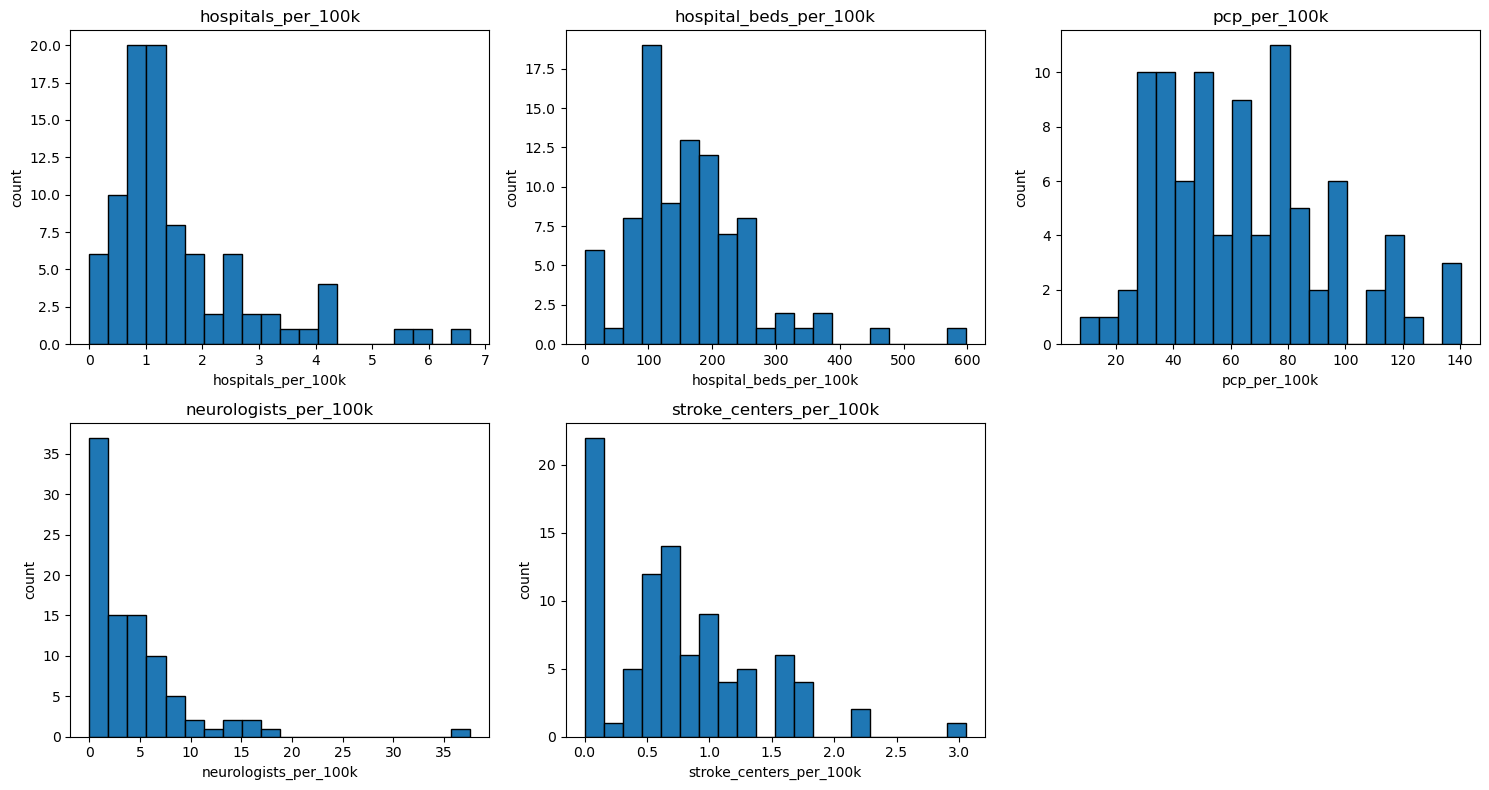

hospitals_per_100k         1.768705
hospital_beds_per_100k     1.315982
pcp_per_100k               0.592278
neurologists_per_100k      3.211727
stroke_centers_per_100k    0.901291
dtype: float64


In [9]:
import matplotlib.pyplot as plt

cols = ['hospitals_per_100k', 'hospital_beds_per_100k', 'pcp_per_100k', 
         'neurologists_per_100k', 'stroke_centers_per_100k']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(scai_data[col], bins=20, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')

axes[-1].axis('off')  # unused subplot
plt.tight_layout()
plt.show()

# Skewness to quantify what the histograms show
print(scai_data[cols].skew())